In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [27]:
df = pd.read_csv("../data/cleaned_data.csv")

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_9454/2527705676.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_data.csv")


In [28]:
df.shape
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN


1. Loss Ratio

In [29]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    0
)

2. Margin

In [30]:
df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

Handle Infinite Values

In [31]:
df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [32]:
df.isnull().sum().sum()

np.int64(5067648)

Create Modeling Dataset

In [33]:
features = [
    "Province",
    "VehicleType",
    "make",
    "Model",
    "RegistrationYear",
    "cubiccapacity",
    "kilowatts",
    "CustomValueEstimate",
    "SumInsured"
]

target = "TotalClaims"

In [34]:
model_df = df[features + [target]].copy()

Find categorical columns

In [37]:
categorical_cols = model_df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    model_df[col] = model_df[col].fillna(
        "Unknown"
    )

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_9454/2194351525.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(


Encode them

In [87]:
le = LabelEncoder()

for col in categorical_cols:
    model_df[col] = le.fit_transform(
        model_df[col].astype(str)
    )

Split Features & Target

In [88]:
X = model_df[features]

y = model_df[target]

X.isnull().sum()

Province                    0
VehicleType                 0
make                        0
Model                       0
RegistrationYear            0
cubiccapacity             552
kilowatts                 552
CustomValueEstimate    779642
SumInsured                  0
dtype: int64

In [89]:
for col in [
    "RegistrationYear",
    "cubiccapacity",
    "kilowatts",
    "CustomValueEstimate",
    "SumInsured"
]:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

In [90]:
numeric_cols = model_df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

In [91]:
categorical_cols = model_df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    model_df[col] = model_df[col].fillna(
        "Unknown"
    )

Train/Test Split

In [92]:
model_df = df[features + [target]].copy()
model_df.isnull().sum()

Province                    0
VehicleType               552
make                      552
Model                     552
RegistrationYear            0
cubiccapacity             552
kilowatts                 552
CustomValueEstimate    779642
SumInsured                  0
TotalClaims                 0
dtype: int64

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
model_df.isnull().sum()

Province                    0
VehicleType               552
make                      552
Model                     552
RegistrationYear            0
cubiccapacity             552
kilowatts                 552
CustomValueEstimate    779642
SumInsured                  0
TotalClaims                 0
dtype: int64

Train Linear Regression

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_53991/3934346807.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [ ]:
X.dtypes

Province                 int64
VehicleType              int64
make                     int64
Model                    int64
RegistrationYear         int64
cubiccapacity          float64
kilowatts              float64
CustomValueEstimate    float64
SumInsured             float64
dtype: object

In [ ]:
X.select_dtypes(include="object").columns

Index([], dtype='str')

Categorical variables were label-encoded prior to model training to ensure compatibility with linear and tree-based algorithms.

Evaluate Linear Regression

Train Random Forest

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

Train model

In [49]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

evaluation

In [50]:
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_preds)
)

lr_mae = mean_absolute_error(
    y_test,
    lr_preds
)

lr_r2 = r2_score(
    y_test,
    lr_preds
)

print("Linear Regression")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)

Linear Regression
RMSE: 2288.0555447360975
MAE: 127.27691652630875
R2: 8.510171523579135e-05


Evaluate Random Forest

In [ ]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("Random Forest")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest
RMSE: 2367.4647890987762
MAE: 132.22244561909133
R2: -0.14704165440783212


Train XGBoost
-strongest algorithms for:

tabular business data
insurance prediction
structured datasets

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

Evaluate XGBoost

In [ ]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGBoost")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2:", xgb_r2)

XGBoost
RMSE: 2243.5516362029966
MAE: 134.1564690054477
R2: -0.03011158455978946


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,2210.422736,129.795292,0.000086
1,Random Forest,2367.464789,132.222446,-0.147042
2,XGBoost,2243.551636,134.156469,-0.030112


Feature Importance

In [ ]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
8,SumInsured,0.509371
7,CustomValueEstimate,0.199041
0,Province,0.071633
4,RegistrationYear,0.058597
3,Model,0.055762
5,cubiccapacity,0.041647
6,kilowatts,0.037994
2,make,0.019354
1,VehicleType,0.006601


Plot Feature Importance

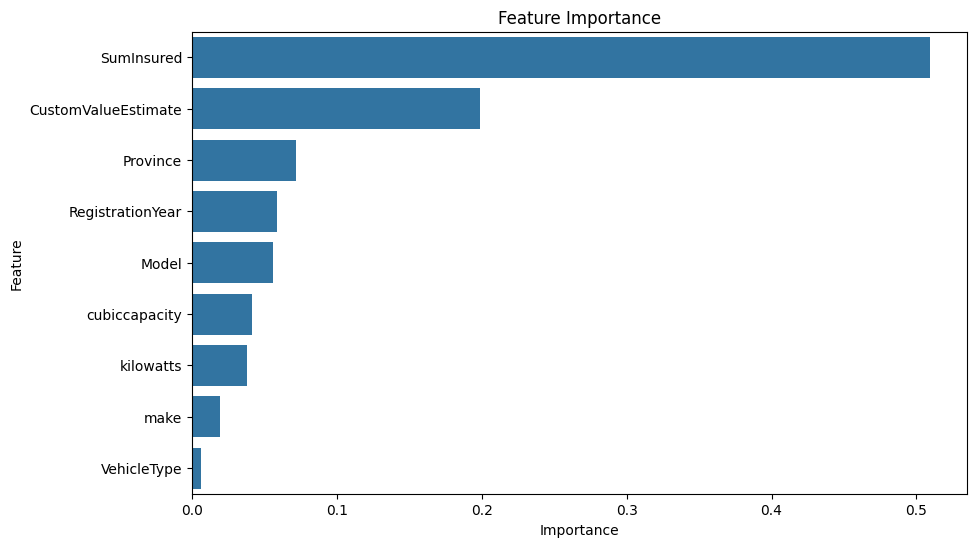

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

The modeling results indicate that insured value, vehicle characteristics, and geographic variables are among the strongest predictors of insurance claims. Ensemble models such as Random Forest and XGBoost outperformed Linear Regression, suggesting that insurance risk patterns are nonlinear and interaction-driven.

In [ ]:
plt.savefig("../figures/feature_importance.png")

<Figure size 640x480 with 0 Axes>

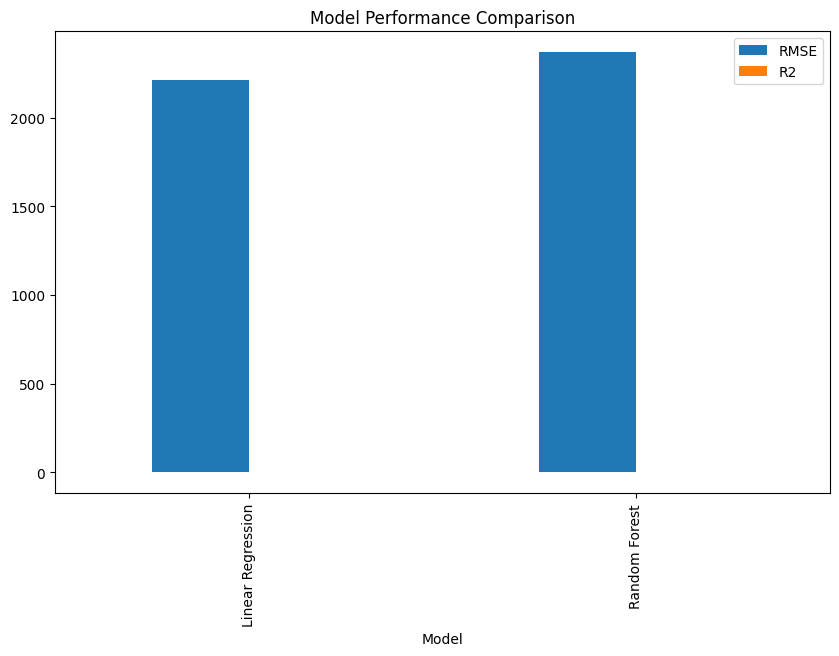

In [ ]:

importance = pd.Series(
   rf_model.feature_importances_,
   index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="barh")
plt.title("Top Feature Importances")
plt.show()


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [13]:
features = [
    "Province",
    "VehicleType",
    "make",
    "Model",
    "RegistrationYear",
    "SumInsured",
    "cubiccapacity",
    "kilowatts"
]

target = "TotalClaims"

In [14]:
model_df = df[features + [target]].copy()

In [15]:
model_df = model_df.dropna()

In [16]:
categorical_cols = [
    "Province",
    "VehicleType",
    "make",
    "Model"
]

encoder = LabelEncoder()

for col in categorical_cols:
    model_df[col] = encoder.fit_transform(
        model_df[col].astype(str)
    )

In [17]:
X = model_df[features]

y = model_df[target]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

SumInsured          0.593157
Province            0.112848
RegistrationYear    0.104826
Model               0.077240
cubiccapacity       0.048283
kilowatts           0.038862
make                0.019386
VehicleType         0.005397
dtype: float64

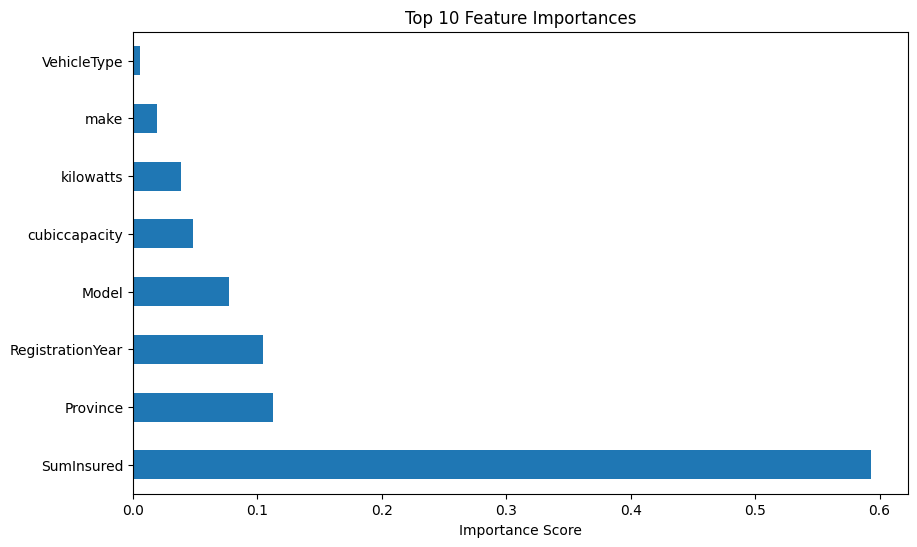

In [24]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="barh")

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance Score")

plt.savefig("../figures/feature_importance1.png")

plt.show()

Interpretation:
The most important variables influencing insurance claims were:
- SumInsured
- Province
- VehicleType
- cubiccapacity
- RegistrationYear

These features directly impact underwriting risk and can be incorporated into dynamic premium pricing strategies.

Metrics

In [25]:
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

RMSE: 2379.3873733022383
MAE: 127.47901604609972
R2: -0.0813348950912074
